# Where new scientific concepts spread next: H2 next-field entry (demo)

This notebook is a runnable demo of `method.py` from the experiment **"Where new scientific concepts spread next"**.

**The full experiment.** It uses a full OpenAlex snapshot (476M works). It follows **653 newborn concepts**, each assigned a *home* venue field, as they enter new venue fields (26 OpenAlex fields). It uses a frozen 26-field PMI relatedness backbone `phi` and each field's *gateway* (eigenvector) centrality `g`.
The analysis has a **dev** half (concepts with a CS/Eng/BGM/Med home, first seen 2003-09). It also has a **held-out** half (all other home fields plus the 2010-14 cohort). The held-out half ran only once, after the dev specification was frozen.

**Hypothesis H2 (entry).** Each year, the analysis asks which field a concept enters next. It compares a baseline conditional logit model **M0** with model **M2**:
- **M0** uses relatedness to the home field, log field size, Hidalgo relatedness density and the target field's own gateway centrality.
- **M2** adds `d_ret_gate`: gateway-weighted relatedness from the fields that currently **retain** the concept to the candidate field.

Model M1 swaps in plain (unweighted) retaining relatedness, and M3 contains both terms. The checks against chance are:
- a concept-bootstrap confidence interval for `d`
- a label-permutation null
- a gateway-only permutation null (M3 vs M1)
- a degree-preserving rewired-backbone null
- a planted positive control

**Full-run result.** On held-out data: LR 71.7 (p = 2e-17) and d = 0.30 [0.24, 0.37], so H2 is confirmed. However, the *gateway weighting* adds little beyond plain retaining relatedness.

**What this demo runs.** It runs the H2 entry pipeline from `method.py` (`h2_block`, `h2_robust`, `planted_control`, the dev → freeze → held-out stages) and its helper libraries (`lib/h2.py`, `lib/stats_core.py`) with the code unchanged. The input is a **curated subset of 100 concepts** (50 dev, 50 held-out) drawn from the real frame. The original bootstrap and permutation counts are kept; on this subset the notebook runs in a few minutes.

The rescue/relay, trajectory and ordering blocks are not run. They need the raw per-work citation tables (several GB) and `tslearn`/`hmmlearn`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, networkx, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'networkx==3.6.1', 'matplotlib==3.10.0')

## Imports
This is the original `method.py` import block. The `lib/` imports (`config`, `frame_io`, `h2`, `stats_core`) are replaced by the inlined library cells below. `networkx`, `scipy` (used by `lib/h2.py` / `lib/stats_core.py`) and `matplotlib` (for the final plots) are added.

In [2]:
from __future__ import annotations

import hashlib
import json
import math
import resource
import sys
import time
import types
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# used by lib/h2.py and lib/stats_core.py
import networkx as nx
from scipy import optimize, stats

import matplotlib.pyplot as plt

## Load the demo data
`mini_demo_data.json` contains:
- `concepts`: 100 newborn concepts with their frame metadata (`cidx`, `t0`, `home`, `group`, `split`, ...). Each concept also has `g`, a `[28 years × 27 slots]` count matrix. `g` counts grounded works per publication year (1995-2022) and venue field (slot 0 = no venue field; slot k = OpenAlex field 10+k).
- `backbone`: the frozen 26×26 PMI relatedness `phi` and the gateway centralities (eigenvector / degree / betweenness).
- `GF`: all-works counts per [year, field], used for field size and the RCA entry definition.
- `reference_full_run`: headline numbers from the full 653-concept run, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-2/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["concepts"]), "concepts;", pd.Series([c["split"] for c in data["concepts"]]).value_counts().to_dict())

100 concepts; {'dev': 50, 'heldout_field': 30, 'heldout_cohort': 20}


## Configuration
These are the constants from the original `config.py`. On this 100-concept subset, the full original resampling counts (2000 bootstrap draws, 1000 permutations, 200 rewirings) still run in about two minutes, so they are kept. Lower them for a quick smoke test.

In [5]:
# ---- tunable parameters (all at the ORIGINAL config.py values; the notebook runs in ~2 min with them) ----
# for a quicker smoke test, e.g. N_BOOT=10, N_PERM=10, N_REWIRE=2, N_PLANTED_NULL=5, N_GROUP_BOOT=10
N_BOOT = 2000         # concept-clustered bootstrap draws (coefficient CI, AUC CIs, power check)
N_PERM = 1000         # label-permutation and gateway-only permutation nulls
N_REWIRE = 200        # degree-preserving rewired-backbone nulls
N_PLANTED_NULL = 100  # null simulations in the T0 planted positive control (planted_control default)
N_GROUP_BOOT = 500    # per-held-out-group bootstrap of d (hard-coded 500 in stage_heldout)

# ---- frozen constants from config.py ----
SEED = 20261001
FIELDS = list(range(11, 37))
NF = 26
Y0, Y1 = 1995, 2022
NY = Y1 - Y0 + 1
DEV_HOME = {17: "CS", 22: "Eng", 13: "BGM", 27: "Med"}
HELDOUT_GROUP = {"Physical": [15, 16, 21, 25, 31], "LifeEnv": [11, 19, 23, 24, 28, 30],
                 "Social": [12, 14, 20, 32, 33], "MathDec": [18, 26], "OtherHealth": [29, 34, 35, 36]}
FIELD_GROUP = {f: g for g, fs in HELDOUT_GROUP.items() for f in fs}
FIELD_GROUP.update({f: "DEV_" + s for f, s in DEV_HOME.items()})

## Estimators (`lib/stats_core.py`)
These functions are copied unchanged. They are the parts `method.py` uses for the H2 block:
- a vectorised **conditional logit** (`CLogit`, Breslow form; only informative strata are kept)
- within-fixed-effects OLS with cluster-robust CRV1 standard errors (`fe_ols`)
- **DerSimonian-Laird** random-effects pooling
- a one-sided sign test

Each stratum is one (concept, year) risk set of candidate fields.

In [6]:
class CLogit:
    '''Each event row e in stratum s contributes x_e.b - log sum_{i in s} exp(x_i.b).
    Rows must be sorted by stratum; `starts` are the first row index of each stratum.'''

    def __init__(self, X: np.ndarray, y: np.ndarray, strata: np.ndarray, ridge: float = 0.0):
        o = np.argsort(strata, kind="stable")
        self.X, self.y, self.s = X[o].astype(float), y[o].astype(float), strata[o]
        self.order = o
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        keep_s = (self.nev > 0) & (self.nev < self.counts)  # informative strata only
        rows = np.repeat(keep_s, self.counts)
        self.X, self.y, self.s = self.X[rows], self.y[rows], self.s[rows]
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        self.ridge = ridge

    def nll(self, b: np.ndarray) -> tuple[float, np.ndarray]:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        mm = np.repeat(m, self.counts)
        w = np.exp(eta - mm)
        S = np.add.reduceat(w, self.starts)
        lse = np.log(S) + m
        ll = float((self.y * eta).sum() - (self.nev * lse).sum())
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)  # per stratum expectation
        g = (self.y[:, None] * self.X).sum(0) - (self.nev[:, None] * Ex).sum(0)
        ll -= 0.5 * self.ridge * float(b @ b)
        g = g - self.ridge * b
        return -ll, -g

    def hessian(self, b: np.ndarray) -> np.ndarray:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        w = np.exp(eta - np.repeat(m, self.counts))
        S = np.add.reduceat(w, self.starts)
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
        Exx = np.add.reduceat(p[:, None, None] * (self.X[:, :, None] * self.X[:, None, :]), self.starts)
        cov = Exx - Ex[:, :, None] * Ex[:, None, :]
        return (self.nev[:, None, None] * cov).sum(0) + self.ridge * np.eye(len(b))

    def fit(self) -> dict:
        k = self.X.shape[1]
        if len(self.starts) == 0:
            return {"coef": np.full(k, np.nan), "se": np.full(k, np.nan), "ll": np.nan, "n_strata": 0, "converged": False}
        r = optimize.minimize(self.nll, np.zeros(k), jac=True, method="L-BFGS-B", options={"maxiter": 500, "gtol": 1e-8})
        H = self.hessian(r.x)
        try:
            se = np.sqrt(np.diag(np.linalg.inv(H)))
        except np.linalg.LinAlgError:
            se = np.full(k, np.nan)
        return {"coef": r.x, "se": se, "ll": -r.fun, "n_strata": int(len(self.starts)), "n_events": int(self.y.sum()),
                "n_rows": int(len(self.y)), "converged": bool(r.success)}


def demean(A: np.ndarray, groups: list[np.ndarray], iters: int = 50, tol: float = 1e-10) -> np.ndarray:
    '''Alternating projections to sweep out several sets of fixed effects.'''
    A = A.astype(float).copy()
    if A.ndim == 1:
        A = A[:, None]
    for _ in range(iters if len(groups) > 1 else 1):
        prev = A.copy()
        for g in groups:
            _, inv = np.unique(g, return_inverse=True)
            cnt = np.bincount(inv)
            for j in range(A.shape[1]):
                A[:, j] -= (np.bincount(inv, weights=A[:, j]) / cnt)[inv]
        if len(groups) > 1 and np.abs(A - prev).max() < tol:
            break
    return A


def fe_ols(y: np.ndarray, X: np.ndarray, fe: list[np.ndarray], cluster: np.ndarray, names: list[str]) -> dict:
    '''OLS of y on X after sweeping out fixed effects `fe`; CRV1 SEs clustered on `cluster` (small-sample corrected).'''
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, cluster = y[ok], X[ok], cluster[ok]
    fe = [g[ok] for g in fe]
    Z = demean(np.column_stack([y, X]), fe) if fe else np.column_stack([y - y.mean(), X - X.mean(0)])
    yd, Xd = Z[:, 0], Z[:, 1:]
    XtX = Xd.T @ Xd
    try:
        XtXi = np.linalg.pinv(XtX)
    except np.linalg.LinAlgError:
        return {"error": "singular"}
    b = XtXi @ Xd.T @ yd
    e = yd - Xd @ b
    _, cinv = np.unique(cluster, return_inverse=True)
    G = cinv.max() + 1
    sc = np.zeros((G, Xd.shape[1]))
    np.add.at(sc, cinv, Xd * e[:, None])
    n, k = Xd.shape
    corr = G / max(G - 1, 1) * (n - 1) / max(n - k, 1)
    V = corr * XtXi @ (sc.T @ sc) @ XtXi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    tcrit = stats.t.ppf(0.975, max(G - 1, 1))
    out = {"n": int(n), "n_clusters": int(G), "coef": {}, "V": V.tolist()}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - tcrit * se[i]), float(b[i] + tcrit * se[i])],
                           "p": float(2 * stats.t.sf(abs(b[i] / se[i]), max(G - 1, 1))) if se[i] > 0 else float("nan")}
    out["_b"] = b
    return out


def dersimonian_laird(b: np.ndarray, se: np.ndarray) -> dict:
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    C = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if k > 1 and C > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def sign_test(k_pos: int, n: int) -> float:
    '''one-sided binomial P(X >= k_pos | p = 0.5).'''
    return float(stats.binom.sf(k_pos - 1, n, 0.5)) if n > 0 else float("nan")

## H2 library (`lib/h2.py`)
This code is copied unchanged.
- `states` turns a concept's `[year × field]` counts into three boolean matrices:
  - *entered*: cumulative count ≥ 2
  - *retaining*: entered at least 2 years earlier, ≥ 2 works in the trailing 3-year window, and off-home
  - *lost*: entered, but no works in the trailing 3-year window
- `build_risk_sets` builds one row per (concept, year t, candidate field k that has not yet been entered) with the six regressors. The outcome is `entered`.
- `recompute_d`, `rewire` and `eig_gateway` produce the permutation and rewired-backbone nulls.

The functions are gathered into an `H2` namespace so the `method.py` code below can call `H2.fit_model(...)` etc. as in the original.

In [7]:
REG = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"]
MODELS = {"M0": ["a_phi_home", "b_log_size", "c_density", "e_gate_own"],
          "M1": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel"],
          "M2": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_ret_gate"],
          "M3": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"],
          "M2lost": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_lost_gate"]}


def states(g: np.ndarray, home: list[int], min_n: int = 2) -> dict:
    '''g: [NY, 27] grounded counts. Returns boolean [NY, 26] matrices (years Y0..).'''
    x = g[:, 1:]
    cum = np.cumsum(x, 0)
    entered = cum >= min_n
    w3 = x.copy()
    w3[1:] += x[:-1]; w3[2:] += x[:-2]
    ent_lag2 = np.zeros_like(entered); ent_lag2[2:] = entered[:-2]
    offhome = np.ones(26, bool)
    for h in home:
        offhome[h - 11] = False
    retaining = ent_lag2 & (w3 >= min_n) & offhome[None, :]
    lost = entered & (w3 == 0)
    return {"entered": entered, "retaining": retaining, "lost": lost, "w3": w3, "cum": cum, "offhome": offhome}


def rca_entered(g: np.ndarray, GF: np.ndarray) -> np.ndarray:
    '''entry when cumulative count >= 2 and the field's cumulative share of the concept exceeds its share of all works.'''
    x = np.cumsum(g[:, 1:], 0)
    tot = x.sum(1, keepdims=True)
    F = np.cumsum(GF, 0)
    share_all = F / np.maximum(F.sum(1, keepdims=True), 1)
    share_c = x / np.maximum(tot, 1)
    ok = (x >= 2) & (share_c > share_all)
    return np.maximum.accumulate(ok.astype(int), 0).astype(bool)


def build_risk_sets(frame: pd.DataFrame, G: dict[int, np.ndarray], bb: dict, GF: np.ndarray,
                    entry_def: str = "count", horizon: int = 8) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    '''Rows = (concept, year t, candidate field k not entered by t-1, not home). Returns df, Ret matrix, Lost matrix.'''
    phi, gate = bb["phi"], bb["g"]
    colsum = phi.sum(0)
    logGF = np.log(np.maximum(GF, 1))
    rows, RET, LOST = [], [], []
    for r in frame.itertuples():
        c = int(r.cidx); t0 = int(r.t0)
        home = [int(h) for h in str(r.home).split("|")]
        S = states(G[c], home)
        ent = rca_entered(G[c], GF) if entry_def == "rca" else S["entered"]
        hidx = [h - 11 for h in home]
        a = phi[hidx].mean(0)
        for t in range(t0 + 1, min(t0 + horizon, 2022) + 1):
            ti = t - Y0
            E = ent[ti - 1]
            cand = ~E & S["offhome"]
            if not cand.any():
                continue
            ev = ent[ti] & cand
            Ret = S["retaining"][ti - 1]
            Lost = S["lost"][ti - 1] & S["offhome"]
            dens = (phi[E].sum(0)) / np.where(colsum > 0, colsum, 1)
            d0 = phi[Ret].mean(0) if Ret.any() else np.zeros(26)
            d = (gate[Ret] @ phi[Ret]) / gate[Ret].sum() if Ret.any() and gate[Ret].sum() > 0 else np.zeros(26)
            dl = (gate[Lost] @ phi[Lost]) / gate[Lost].sum() if Lost.any() and gate[Lost].sum() > 0 else np.zeros(26)
            for k in np.nonzero(cand)[0]:
                rows.append((c, t, t - t0, k + 11, int(ev[k]), a[k], logGF[ti - 1, k], dens[k], gate[k], d0[k], d[k], dl[k],
                             int(Ret.sum()), int(Lost.sum()), r.group, r.split, int(r.intersection_born), float(r.home_gateway)))
                RET.append(Ret); LOST.append(Lost)
    df = pd.DataFrame(rows, columns=["cidx", "t", "age", "field", "entered", "a_phi_home", "b_log_size", "c_density",
                                     "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "n_ret", "n_lost", "group",
                                     "split", "intersection_born", "home_gateway"])
    df["stratum"] = df.cidx.astype(np.int64) * 100 + (df.t - 2000)
    return df, np.array(RET, bool).reshape(-1, 26), np.array(LOST, bool).reshape(-1, 26)


def standardise(df: pd.DataFrame, spec: dict | None, cols: list[str]) -> tuple[pd.DataFrame, dict]:
    if spec is None:
        spec = {c: {"mean": float(df[c].mean()), "sd": float(df[c].std() or 1.0)} for c in cols}
    out = df.copy()
    for c in cols:
        out[c] = (df[c] - spec[c]["mean"]) / (spec[c]["sd"] if spec[c]["sd"] > 0 else 1.0)
    return out, spec


def fit_model(df: pd.DataFrame, cols: list[str], ridge: float = 0.0) -> dict:
    m = CLogit(df[cols].to_numpy(), df.entered.to_numpy(), df.stratum.to_numpy(), ridge=ridge).fit()
    return {"coef": dict(zip(cols, map(float, m["coef"]))), "se": dict(zip(cols, map(float, m["se"]))), "ll": m["ll"],
            "n_strata": m["n_strata"], "n_events": m.get("n_events", 0), "n_rows": m.get("n_rows", 0),
            "converged": m["converged"], "_b": m["coef"]}


def lr_test(big: dict, small: dict, df_: int) -> dict:
    lr = 2 * (big["ll"] - small["ll"])
    return {"LR": float(lr), "df": df_, "p": float(stats.chi2.sf(max(lr, 0), df_))}


def within_auc(df: pd.DataFrame, score: np.ndarray) -> pd.Series:
    '''mean-rank AUC per informative stratum.'''
    d = pd.DataFrame({"s": df.stratum.to_numpy(), "y": df.entered.to_numpy(), "x": score})
    d["r"] = d.groupby("s").x.rank(method="average")
    g = d.groupby("s").agg(ntot=("y", "size"), nev=("y", "sum"))
    re = d[d.y == 1].groupby("s").r.sum()
    g = g.join(re.rename("rs")).fillna({"rs": 0})
    g = g[(g.nev > 0) & (g.nev < g.ntot)]
    nn = g.ntot - g.nev
    return (g.rs - g.nev * (g.nev + 1) / 2) / (g.nev * nn)


def concept_boot_mean(series: pd.Series, n_boot: int, rng) -> list[float]:
    '''series indexed by stratum id (cidx*100 + ...): concept-clustered bootstrap CI of the mean.'''
    cid = (series.index.to_numpy() // 100)
    u, inv = np.unique(cid, return_inverse=True)
    sums = np.bincount(inv, weights=series.to_numpy()); cnts = np.bincount(inv)
    bs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(u), len(u))
        bs.append(sums[pick].sum() / max(cnts[pick].sum(), 1))
    return [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]


def boot_coef(df: pd.DataFrame, cols: list[str], target: str, n_boot: int, rng, small_cols: list[str] | None = None) -> dict:
    '''concept-clustered bootstrap of a clogit coefficient (and the LR vs small model if given).'''
    cids = df.cidx.unique()
    by = {c: ix for c, ix in df.groupby("cidx").indices.items()}
    X = df[cols].to_numpy(); y = df.entered.to_numpy(); st = df.stratum.to_numpy()
    Xs = df[small_cols].to_numpy() if small_cols else None
    bs, lrs = [], []
    for b in range(n_boot):
        pick = rng.choice(cids, len(cids))
        idx = np.concatenate([by[c] for c in pick])
        rep = np.repeat(np.arange(len(pick)), [len(by[c]) for c in pick])
        s2 = st[idx] * 10000 + rep  # relabel strata of repeated concepts
        m = CLogit(X[idx], y[idx], s2).fit()
        bs.append(m["coef"][cols.index(target)])
        if small_cols:
            ms = CLogit(Xs[idx], y[idx], s2).fit()
            lrs.append(2 * (m["ll"] - ms["ll"]))
    bs = np.array(bs)
    out = {"ci": [float(np.nanpercentile(bs, 2.5)), float(np.nanpercentile(bs, 97.5))], "se_boot": float(np.nanstd(bs)),
           "n_boot": n_boot}
    if small_cols:
        out["lr_boot"] = [float(x) for x in np.percentile(lrs, [5, 25, 50, 75, 95])]
        out["_lrs"] = np.array(lrs)
    return out


def recompute_d(RET: np.ndarray, fields: np.ndarray, phi: np.ndarray, gate: np.ndarray) -> np.ndarray:
    k = fields - 11
    w = RET * gate[None, :]
    den = w.sum(1)
    num = (w * phi[:, k].T).sum(1)
    return np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)


def eig_gateway(phi: np.ndarray) -> np.ndarray:
    Gx = nx.from_numpy_array(phi)
    try:
        ev = nx.eigenvector_centrality_numpy(Gx, weight="weight")
    except Exception:  # noqa: BLE001 -- disconnected graph after rewiring: fall back to power iteration
        ev = nx.eigenvector_centrality(Gx, weight="weight", max_iter=2000)
    v = np.array([ev[i] for i in range(len(phi))])
    v = np.abs(v)
    return v / v.max()


def rewire(phi: np.ndarray, rng) -> np.ndarray:
    '''degree-preserving double-edge swaps on the phi>0 graph; original weights reassigned at random to the new edges.'''
    Gx = nx.Graph()
    Gx.add_nodes_from(range(len(phi)))
    iu = np.transpose(np.nonzero(np.triu(phi, 1) > 0))
    Gx.add_edges_from(map(tuple, iu))
    ne = Gx.number_of_edges()
    try:
        nx.double_edge_swap(Gx, nswap=10 * ne, max_tries=1000 * ne, seed=int(rng.integers(1 << 31)))
    except nx.NetworkXAlgorithmError:
        pass
    w = phi[iu[:, 0], iu[:, 1]].copy()
    rng.shuffle(w)
    P = np.zeros_like(phi)
    for (i, j), wt in zip(Gx.edges(), w):
        P[i, j] = P[j, i] = wt
    return P


# namespace so method.py code can keep calling H2.<fn>
H2 = types.SimpleNamespace(MODELS=MODELS, states=states, rca_entered=rca_entered, build_risk_sets=build_risk_sets,
                           standardise=standardise, fit_model=fit_model, lr_test=lr_test, within_auc=within_auc,
                           concept_boot_mean=concept_boot_mean, boot_coef=boot_coef, recompute_d=recompute_d,
                           eig_gateway=eig_gateway, rewire=rewire)

## Data access (replaces `lib/frame_io.py` and the `.npz` scan files)
In the original, these loaders read `inputs/field_backbone.json`, `scan/frame_g_*.npz`, `results/frame_concepts.csv` and `scan/agg_counts.npz`. Here they build the same objects from `data`. The sealing guard is not needed: the held-out outcomes in the demo subset come from the original run, after its freeze.

In [8]:
def load_backbone() -> dict:
    b = dict(data["backbone"])
    b["phi"] = np.array(b["phi"]); b["g"] = np.array(b["gateway_eig"])
    b["g_deg"] = np.array(b["gateway_deg"]); b["g_btw"] = np.array(b["gateway_btw"])
    return b


def load_g(split: str) -> dict[int, np.ndarray]:
    '''per-concept grounded counts [NY, 27] (slot 0 = no venue field, slot k = field 10+k).'''
    keep = (lambda s: s == "dev") if split == "dev" else (lambda s: s != "dev")
    return {int(c["cidx"]): np.array(c["g"], dtype=float) for c in data["concepts"] if keep(c["split"])}


def load_frame(split: str | None = None) -> pd.DataFrame:
    fc = pd.DataFrame([{k: v for k, v in c.items() if k != "g"} for c in data["concepts"]])
    if split is None:
        return fc
    if split == "heldout":
        return fc[fc.split.isin(["heldout_field", "heldout_cohort"])]
    return fc[fc.split == split]


def agg():
    # original: np.load(SCAN / "agg_counts.npz") -> (G, GF); only GF (all works per [year, field]) is used by H2
    return None, np.array(data["GF"])


bb_demo = load_backbone()
print("fields:", bb_demo["fields"][:5], "...", "| phi", bb_demo["phi"].shape, "| GF", agg()[1].shape)
print(load_frame()[["cidx", "name", "t0", "home", "group", "split"]].head(8).to_string(index=False))

fields: ['Agricultural and Biological Sciences', 'Arts and Humanities', 'Biochemistry, Genetics and Molecular Biology', 'Business, Management and Accounting', 'Chemical Engineering'] ... | phi (26, 26) | GF (28, 26)
 cidx                      name   t0 home   group split
36364               Bevacizumab 2004   27 DEV_Med   dev
38988                Atazanavir 2003   27 DEV_Med   dev
39390 High resolution manometry 2009   27 DEV_Med   dev
33785               Tocilizumab 2007   27 DEV_Med   dev
40718                Dabigatran 2007   27 DEV_Med   dev
51269      Cardiorenal syndrome 2009   27 DEV_Med   dev
45143                 Aliskiren 2006   27 DEV_Med   dev
28984                Fingolimod 2008   27 DEV_Med   dev


## `method.py`: logger, regressor list and the H2 blocks
This code is copied from `method.py` with only these changes:
- the loguru file sink under `logs/` is dropped
- `planted_control` takes its null-simulation count from the config cell

The main functions:
- **`h2_block`** fits M0-M3 and M2lost on the *primary sample*, i.e. concept-year strata whose retaining set is not empty. It then computes:
  - LR tests
  - within-stratum AUCs per model and per regressor
  - a concept-clustered bootstrap of `d`
  - a label-permutation null (fields permuted jointly in `phi` and `g`)
  - a gateway-only permutation null (M3 vs M1)
  - a degree-preserving rewired-backbone null
- **`h2_robust`** runs robustness variants:
  - a linear probability model with concept-year and field fixed effects
  - all strata, with an empty-retaining-set indicator
  - excluding intersection-born concepts
  - a home-is-top-gateway interaction
  - degree and betweenness gateways
  - an RCA entry definition
- **`planted_control`** plants an effect of β = 1 on the real risk-set structure and checks that it is detected, and that the no-effect (β = 0) null rejects at about its nominal rate.

In [9]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
REGS = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate"]
HELD_GROUPS = ["Physical", "LifeEnv", "Social", "MathDec", "Cohort"]


def gate_terciles(gate: np.ndarray) -> tuple[float, float]:
    return float(np.quantile(gate, 1 / 3)), float(np.quantile(gate, 2 / 3))


# =============================================================================== H2
def h2_block(df: pd.DataFrame, spec: dict | None, rng, n_boot: int, n_perm: int, n_rewire: int, bb: dict,
             RET: np.ndarray, full: bool = True) -> tuple[dict, dict]:
    '''fit M0-M3 on the primary sample (strata with a non-empty retaining set).'''
    dfs, spec = H2.standardise(df, spec, REGS)
    res = {"n_rows": len(dfs), "n_strata": int(dfs.stratum.nunique()), "n_concepts": int(dfs.cidx.nunique()),
           "n_events": int(dfs.entered.sum()), "entry_rate": float(dfs.entered.mean())}
    fits = {m: H2.fit_model(dfs, cols) for m, cols in H2.MODELS.items()}
    res["models"] = {m: {k: v for k, v in f.items() if k != "_b"} for m, f in fits.items()}
    res["LR"] = {"M2_vs_M0": H2.lr_test(fits["M2"], fits["M0"], 1), "M1_vs_M0": H2.lr_test(fits["M1"], fits["M0"], 1),
                 "M3_vs_M1": H2.lr_test(fits["M3"], fits["M1"], 1), "M2lost_vs_M0": H2.lr_test(fits["M2lost"], fits["M0"], 1)}
    # within-stratum AUC per block (linear predictor) and per single regressor
    auc = {}
    for m, cols in H2.MODELS.items():
        s = H2.within_auc(dfs, dfs[cols].to_numpy() @ fits[m]["_b"])
        auc[m] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, n_boot, rng), "n_strata": int(len(s))}
    for c in REGS:
        s = H2.within_auc(dfs, dfs[c].to_numpy())
        auc[c] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, n_boot, rng)}
    res["auc_within_stratum"] = auc
    if not full:
        return res, spec
    t = time.time()
    res["boot_d"] = H2.boot_coef(dfs, H2.MODELS["M2"], "d_ret_gate", n_boot, rng, small_cols=H2.MODELS["M0"])
    logger.info(f"bootstrap {n_boot} in {time.time()-t:.0f}s")
    # label-permutation null for d (phi and g permuted jointly across fields)
    phi, gate = bb["phi"], bb["g"]
    lr_obs = res["LR"]["M2_vs_M0"]["LR"]
    fields = df.field.to_numpy()
    base = dfs.copy()
    mu, sd = spec["d_ret_gate"]["mean"], spec["d_ret_gate"]["sd"]
    perm = []
    for _ in range(n_perm):
        p = rng.permutation(26)
        dp = H2.recompute_d(RET, fields, phi[np.ix_(p, p)], gate[p])
        base["d_ret_gate"] = (dp - mu) / sd
        perm.append(2 * (H2.fit_model(base, H2.MODELS["M2"])["ll"] - fits["M0"]["ll"]))
    perm = np.array(perm)
    res["perm_null"] = {"n": n_perm, "lr_obs": lr_obs, "p": float((1 + (perm >= lr_obs).sum()) / (1 + n_perm)),
                        "null_q": np.percentile(perm, [50, 90, 95, 99]).tolist(), "null_mean": float(perm.mean())}
    gperm = []
    lr31 = res["LR"]["M3_vs_M1"]["LR"]
    for _ in range(n_perm):
        p = rng.permutation(26)
        dp = H2.recompute_d(RET, fields, phi, gate[p])
        base["d_ret_gate"] = (dp - mu) / sd
        gperm.append(2 * (H2.fit_model(base, H2.MODELS["M3"])["ll"] - fits["M1"]["ll"]))
    gperm = np.array(gperm)
    res["gonly_perm_null_M3_vs_M1"] = {"n": n_perm, "lr_obs": lr31, "p": float((1 + (gperm >= lr31).sum()) / (1 + n_perm)),
                                       "null_q": np.percentile(gperm, [50, 90, 95, 99]).tolist()}
    base["d_ret_gate"] = dfs["d_ret_gate"]
    rew = []
    for _ in range(n_rewire):
        P = H2.rewire(phi, rng)
        gp = H2.eig_gateway(P)
        dp = H2.recompute_d(RET, fields, P, gp)
        base["d_ret_gate"] = (dp - mu) / sd
        rew.append(2 * (H2.fit_model(base, H2.MODELS["M2"])["ll"] - fits["M0"]["ll"]))
    rew = np.array(rew)
    res["rewired_null"] = {"n": n_rewire, "lr_obs": lr_obs, "p": float((1 + (rew >= lr_obs).sum()) / (1 + n_rewire)),
                           "null_q95": float(np.percentile(rew, 95)), "null_median": float(np.median(rew)),
                           "real_gain_le_null95": bool(lr_obs <= np.percentile(rew, 95))}
    res["_lrs_boot"] = res["boot_d"].pop("_lrs")
    return res, spec


def h2_robust(df_all: pd.DataFrame, spec: dict, frame: pd.DataFrame, G: dict, bb: dict, GF: np.ndarray, Gpf: dict | None) -> dict:
    out = {}
    prim = df_all[df_all.n_ret > 0]
    dfs, _ = H2.standardise(prim, spec, REGS)
    # LPM with concept-year and field FE, CRV1 by concept
    X = dfs[["a_phi_home", "b_log_size", "c_density", "d_ret_gate"]].to_numpy()
    r = fe_ols(dfs.entered.to_numpy().astype(float), X, [dfs.stratum.to_numpy(), dfs.field.to_numpy()], dfs.cidx.to_numpy(),
               ["a_phi_home", "b_log_size", "c_density", "d_ret_gate"])
    out["LPM_conceptyear_field_FE"] = {k: v for k, v in r.items() if k not in ("_b", "V")}
    # secondary sample: all strata with an empty-retaining-set indicator
    dall, _ = H2.standardise(df_all, spec, REGS)
    dall["ret_empty"] = (df_all.n_ret == 0).astype(float).to_numpy()
    f0 = H2.fit_model(dall, H2.MODELS["M0"] + ["ret_empty"]); f2 = H2.fit_model(dall, H2.MODELS["M2"] + ["ret_empty"])
    out["secondary_all_strata"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"],
                                   "LR": H2.lr_test(f2, f0, 1), "n_strata": f2["n_strata"]}
    # excluding intersection-born
    d = dfs[dfs.intersection_born == 0]
    f0 = H2.fit_model(d, H2.MODELS["M0"]); f2 = H2.fit_model(d, H2.MODELS["M2"])
    out["excl_intersection_born"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1)}
    # boundary stratum: home is a top-tercile gateway
    lo, hi = gate_terciles(bb["g"])
    d = dfs.copy()
    d["home_top"] = (d.home_gateway >= hi).astype(float)
    d["d_x_home_top"] = d.d_ret_gate * d.home_top
    f = H2.fit_model(d, H2.MODELS["M2"] + ["d_x_home_top"])
    out["boundary_home_top_gateway"] = {"d_coef_home_not_top": f["coef"]["d_ret_gate"], "interaction": f["coef"]["d_x_home_top"],
                                        "interaction_se": f["se"]["d_x_home_top"], "n_home_top_concepts": int(d[d.home_top == 1].cidx.nunique())}
    # alternative gateway definitions (degree, betweenness) for d
    for kind in ("g_deg", "g_btw"):
        bb2 = dict(bb); bb2["g"] = bb[kind]
        dfk, RETk, _ = H2.build_risk_sets(frame, G, bb2, GF)
        dfk = dfk[dfk.n_ret > 0]
        dks, _ = H2.standardise(dfk, None, REGS)
        f0 = H2.fit_model(dks, H2.MODELS["M0"]); f2 = H2.fit_model(dks, H2.MODELS["M2"])
        out[f"gateway_{kind}"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1)}
    # RCA-based entry definition
    dfr, _, _ = H2.build_risk_sets(frame, G, bb, GF, entry_def="rca")
    dfr = dfr[dfr.n_ret > 0]
    drs, _ = H2.standardise(dfr, None, REGS)
    f0 = H2.fit_model(drs, H2.MODELS["M0"]); f2 = H2.fit_model(drs, H2.MODELS["M2"])
    out["rca_entry"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"], "LR": H2.lr_test(f2, f0, 1),
                        "n_events": f2["n_events"]}
    if Gpf is not None:
        dfp, _, _ = H2.build_risk_sets(frame[frame.cidx.isin(list(Gpf))], Gpf, bb, GF)
        dfp = dfp[dfp.n_ret > 0]
        dps, _ = H2.standardise(dfp, None, REGS)
        f0 = H2.fit_model(dps, H2.MODELS["M0"]); f2 = H2.fit_model(dps, H2.MODELS["M2"])
        out["primary_topic_field_labels"] = {"d_coef": f2["coef"]["d_ret_gate"], "d_se": f2["se"]["d_ret_gate"],
                                             "LR": H2.lr_test(f2, f0, 1)}
    return out


def planted_control(df: pd.DataFrame, spec: dict, rng, n_sim: int = N_PLANTED_NULL) -> dict:  # original default n_sim=100
    '''T0 planted positive control on the REAL risk-set structure: one event per stratum with P ~ exp(beta*d).'''
    dfs, _ = H2.standardise(df, spec, REGS)
    dfs = dfs.sort_values("stratum").reset_index(drop=True)
    st = dfs.stratum.to_numpy(); u, starts = np.unique(st, return_index=True)
    ends = np.append(starts[1:], len(st))

    def sim(beta: float) -> float:
        y = np.zeros(len(dfs))
        eta = beta * dfs.d_ret_gate.to_numpy() + 0.8 * dfs.b_log_size.to_numpy()
        for s, e in zip(starts, ends):
            p = np.exp(eta[s:e] - eta[s:e].max()); p /= p.sum()
            y[s + rng.choice(e - s, p=p)] = 1
        d2 = dfs.assign(entered=y)
        return H2.lr_test(H2.fit_model(d2, H2.MODELS["M2"]), H2.fit_model(d2, H2.MODELS["M0"]), 1)["p"]
    pos = [sim(1.0) for _ in range(10)]
    null = [sim(0.0) for _ in range(n_sim)]
    return {"planted_beta1_p_median": float(np.median(pos)), "planted_detect_rate_p<0.001": float(np.mean(np.array(pos) < 1e-3)),
            "null_reject_rate_0.01": float(np.mean(np.array(null) < 0.01)), "n_null_sims": n_sim}

## Stage 1: dev (`stage_dev`, H2 part)
This is the body of `stage_dev()`, split into cells. It loads the backbone, the dev frame and the per-concept counts. It then builds the concept-year risk sets and keeps the primary sample (non-empty retaining set). `h2_block` is fitted with a fresh standardisation `spec`, which is estimated on dev data and frozen later.

In the original, `df_all` was also written to `results/entry_risk_sets_dev.parquet`; that write is skipped here.

In [10]:
t_stage = time.time()
rng = np.random.default_rng(SEED)
bb = load_backbone(); G_tot, GF = agg()
frame = load_frame("dev"); frame = frame[frame.newborn]
G = load_g("dev")
res = {"n_dev_concepts_newborn": int(len(frame)), "dev_by_group": frame.group.value_counts().to_dict()}
t = time.time()
df_all, RET_all, _ = H2.build_risk_sets(frame, G, bb, GF)
prim = df_all.n_ret > 0
df, RET = df_all[prim].reset_index(drop=True), RET_all[prim.to_numpy()]
logger.info(f"dev risk sets: {len(df_all):,} rows, primary {len(df):,} rows / {df.stratum.nunique():,} strata "
            f"({time.time()-t:.0f}s)")
df.head()

21:10:06|INFO   |dev risk sets: 8,350 rows, primary 6,484 rows / 320 strata (0s)


,cidx,t,age,field,entered,a_phi_home,b_log_size,c_density,e_gate_own,d0_ret_rel,d_ret_gate,d_lost_gate,n_ret,n_lost,group,split,intersection_born,home_gateway,stratum
0,36364,2007,3,11,0,0.0,11.562392,0.179581,0.284100,0.000000,0.000000,0.0,1,0,DEV_Med,dev,0,0.299723,3636407
1,36364,2007,3,12,0,0.0,11.536886,0.150641,0.025349,0.228902,0.228902,0.0,1,0,DEV_Med,dev,0,0.299723,3636407
2,36364,2007,3,14,0,0.0,10.467551,0.489434,0.077116,0.054282,0.054282,0.0,1,0,DEV_Med,dev,0,0.299723,3636407
3,36364,2007,3,15,0,0.0,4.718499,0.000000,0.963895,0.000000,0.000000,0.0,1,0,DEV_Med,dev,0,0.299723,3636407
4,36364,2007,3,16,0,0.0,11.290669,0.082956,1.000000,0.000000,0.000000,0.0,1,0,DEV_Med,dev,0,0.299723,3636407


### Fit M0-M3 and run the nulls on dev

In [11]:
h, spec = h2_block(df, None, rng, N_BOOT, N_PERM, N_REWIRE, bb, RET)
lrs = h.pop("_lrs_boot")
res["H2"] = h
res["H2"]["size_vs_density_auc"] = {"size": h["auc_within_stratum"]["b_log_size"]["mean"],
                                    "density": h["auc_within_stratum"]["c_density"]["mean"]}
logger.info(f"H2 dev: LR M2vsM0={h['LR']['M2_vs_M0']}, d={h['models']['M2']['coef']['d_ret_gate']:.3f}")
pd.DataFrame({m: v["coef"] for m, v in h["models"].items()}).round(3)

21:10:16|INFO   |bootstrap 2000 in 10s


21:10:30|INFO   |H2 dev: LR M2vsM0={'LR': 4.8599581842781845, 'df': 1, 'p': 0.02748700230657696}, d=0.194


,M0,M1,M2,M3,M2lost
a_phi_home,0.337,0.364,0.361,0.365,0.337
b_log_size,1.494,1.556,1.550,1.557,1.495
c_density,0.406,0.319,0.326,0.316,0.403
e_gate_own,0.184,0.135,0.103,0.114,0.184
d0_ret_rel,NaN,0.187,NaN,0.097,NaN
d_ret_gate,NaN,NaN,0.194,0.107,NaN
d_lost_gate,NaN,NaN,NaN,NaN,0.035


### Robustness variants, planted control and power check
`Gpf`, the primary-topic field labels from `scan/frame_gpf_dev.npz`, is not part of the demo data. As a result, `primary_topic_field_labels` is skipped, just as in the original when that file is missing.

In [12]:
Gpf = None
res["H2_robustness"] = h2_robust(df_all, spec, frame, G, bb, GF, Gpf)
res["T0_planted_control"] = planted_control(df, spec, rng)
logger.info(f"planted control: {res['T0_planted_control']}")
# power at held-out n: share of bootstrap LR draws significant at 0.01, rescaled to the held-out concept count
nh = len(load_frame().query("split != 'dev' and newborn"))
scale = nh / max(frame.shape[0], 1)
from scipy import stats as st
res["power_check"] = {"n_heldout_concepts": nh, "scale_vs_dev": scale,
                      "P(p<0.01) at heldout n (LR scaled linearly)": float(np.mean(st.chi2.sf(lrs * scale, 1) < 0.01))}
dev_result = res
print(json.dumps({k: (v["d_coef"] if isinstance(v, dict) and "d_coef" in v else "...") for k, v in res["H2_robustness"].items()}, indent=1))
print(res["T0_planted_control"]); print(res["power_check"])
logger.info(f"dev stage (H2) done in {time.time()-t_stage:.0f}s")

/tmp/ipykernel_618/2239439005.py:51: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(np.linalg.inv(H)))
/tmp/ipykernel_618/2239439005.py:51: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(np.linalg.inv(H)))


21:10:32|INFO   |planted control: {'planted_beta1_p_median': 2.8157360639005028e-59, 'planted_detect_rate_p<0.001': 1.0, 'null_reject_rate_0.01': 0.01, 'n_null_sims': 100}


{
 "LPM_conceptyear_field_FE": "...",
 "secondary_all_strata": 0.1911260287962356,
 "excl_intersection_born": 0.22042992163463204,
 "boundary_home_top_gateway": "...",
 "gateway_g_deg": 0.1582480622056327,
 "gateway_g_btw": 0.1345817861226382,
 "rca_entry": 0.2730159088075623
}
{'planted_beta1_p_median': 2.8157360639005028e-59, 'planted_detect_rate_p<0.001': 1.0, 'null_reject_rate_0.01': 0.01, 'n_null_sims': 100}
{'n_heldout_concepts': 50, 'scale_vs_dev': 1.0, 'P(p<0.01) at heldout n (LR scaled linearly)': 0.3755}
21:10:32|INFO   |dev stage (H2) done in 26s


## Stage 2: freeze (`stage_freeze`, simplified)
In the original, this stage writes `results/frozen_spec.json`. That file holds the dev standardisation, the model definitions and the pre-registered decision rules, and its SHA-256 is logged to `freeze_log.txt` before the held-out data is unsealed. Here the spec is kept in memory and hashed in the same way.

In [13]:
lo, hi = gate_terciles(bb["g"])
frozen_spec = {"created": datetime.now(timezone.utc).isoformat(), "models": H2.MODELS,
               "primary_sample": "strata (concept, t) with non-empty retaining set; t = t0+1..t0+8",
               "standardisation": spec, "gate_terciles": [lo, hi],
               "decision_rules": {
                   "H2_entry_CONFIRMED": "LR M2 vs M0 p<0.01 AND pooled d>0 with concept-bootstrap 95% CI>0 AND d>0 in >= ceil(0.75 x available held-out FIELD groups) (MathDec has no concepts -> 3 of 3: Physical, LifeEnv, Social) AND d>0 in the 2010-14 cohort AND permutation p<0.05 AND real LR gain > 95th pct of the rewired-backbone null"}}
print("frozen spec sha256 =", hashlib.sha256(json.dumps(frozen_spec, sort_keys=True, default=str).encode()).hexdigest())

frozen spec sha256 = 02761a57c8e73d72ca8f3ea6945461e94faec29a17c51d9f98a0c8f1e184a6c1


## Stage 3: held-out (`stage_heldout`, H2 part)
This stage re-uses the **frozen dev standardisation**. It uses a different seed (SEED + 7) and labels the 2010-14 cohort split as group `Cohort`. It then does four things:
1. Refits the H2 block on the pooled held-out sample.
2. Scores the **frozen dev coefficients** on held-out data with no refit, giving a prediction AUC.
3. Fits M0/M2 separately in each held-out group, with a bootstrap CI for `d`.
4. Pools the per-group `d` values with DerSimonian-Laird.

In the original, the held-out outcomes were first unsealed with `frame.concept_outcomes`. The demo data already contains the unsealed frame.

In [14]:
t_stage = time.time()
spec = frozen_spec
rng = np.random.default_rng(SEED + 7)
bb = load_backbone(); G_tot, GF = agg()
fc = load_frame()
G = load_g("heldout")
frame = fc[(fc.split != "dev") & fc.newborn].copy()
frame["hgroup"] = np.where(frame.split == "heldout_cohort", "Cohort", frame.group)
res = {"n_heldout_concepts": int(len(frame)), "by_group": frame.hgroup.value_counts().to_dict()}
df_all, RET_all, _ = H2.build_risk_sets(frame, G, bb, GF)
df_all["hgroup"] = df_all.cidx.map(dict(zip(frame.cidx, frame.hgroup)))
prim = (df_all.n_ret > 0).to_numpy()
df, RET = df_all[prim].reset_index(drop=True), RET_all[prim]
std = spec["standardisation"]
h, _ = h2_block(df, std, rng, N_BOOT, N_PERM, N_REWIRE, bb, RET)
h.pop("_lrs_boot", None)
res["H2_pooled"] = h
print(res["by_group"]); print(h["LR"]["M2_vs_M0"], "d =", round(h["models"]["M2"]["coef"]["d_ret_gate"], 3), "boot CI", h["boot_d"]["ci"])

21:10:43|INFO   |bootstrap 2000 in 10s


{'Cohort': 20, 'Physical': 10, 'LifeEnv': 10, 'Social': 10}
{'LR': 5.783714863476121, 'df': 1, 'p': 0.016175319444840512} d = 0.215 boot CI [0.10179403539215606, 0.3307845088368819]


### Frozen-coefficient prediction, per-group fits and DL pooling

In [15]:
# frozen dev coefficients scored on held-out (prediction AUC, no refit)
dev = dev_result  # original: json.loads((RES / "dev_result.json").read_text())
dfs, _ = H2.standardise(df, std, REGS)
for mname in ("M0", "M2"):
    b = np.array([dev["H2"]["models"][mname]["coef"][c] for c in H2.MODELS[mname]])
    s = H2.within_auc(dfs, dfs[H2.MODELS[mname]].to_numpy() @ b)
    res.setdefault("frozen_dev_coef_auc", {})[mname] = {"mean": float(s.mean()), "ci": H2.concept_boot_mean(s, N_BOOT, rng)}
per = {}
for gname in HELD_GROUPS + ["OtherHealth"]:
    d = df[df.hgroup == gname]
    if d.cidx.nunique() < 5:
        per[gname] = {"n_concepts": int(d.cidx.nunique()), "status": "too few concepts"}
        continue
    ds, _ = H2.standardise(d, std, REGS)
    f0 = H2.fit_model(ds, H2.MODELS["M0"]); f2 = H2.fit_model(ds, H2.MODELS["M2"])
    bt = H2.boot_coef(ds, H2.MODELS["M2"], "d_ret_gate", N_GROUP_BOOT, rng)  # original: 500 draws
    per[gname] = {"n_concepts": int(d.cidx.nunique()), "n_events": f2["n_events"], "d": f2["coef"]["d_ret_gate"],
                  "se": f2["se"]["d_ret_gate"], "boot_ci": bt["ci"], "LR": H2.lr_test(f2, f0, 1)}
res["H2_per_group"] = per
use = [g for g in HELD_GROUPS if "d" in per.get(g, {})]
res["H2_DL_pooled"] = dersimonian_laird(np.array([per[g]["d"] for g in use]), np.array([per[g]["se"] for g in use]))
npos = sum(per[g]["d"] > 0 for g in use)
res["H2_sign_count"] = {"positive": int(npos), "of": len(use), "sign_test_p": sign_test(npos, len(use))}
print(res["frozen_dev_coef_auc"]); print(res["H2_DL_pooled"]); print(res["H2_sign_count"])

{'M0': {'mean': 0.817525736245304, 'ci': [0.7919261337657006, 0.8427143317376858]}, 'M2': {'mean': 0.8219842810260924, 'ci': [0.7956260106601073, 0.8463840525901953]}}
{'k': 4, 'b': 0.18669676110449768, 'se': 0.09011235978666134, 'ci': [0.01007653592264146, 0.3633169862863539], 'p': 0.038282052884285336, 'tau2': 0.0, 'Q': 0.8449782188265704, 'I2': 0.0}
{'positive': 3, 'of': 4, 'sign_test_p': 0.3125}


### Pre-registered H2 entry decision
This decision rule is copied from `stage_heldout`. The rescue, relay and ordering decisions need the blocks that the demo does not run.

In [16]:
lr = h["LR"]["M2_vs_M0"]
ci = h["boot_d"]["ci"]
fg = [g for g in ("Physical", "LifeEnv", "Social", "MathDec") if "d" in per.get(g, {})]
grp_pos = sum(per[g]["d"] > 0 for g in fg)
need = math.ceil(0.75 * len(fg))
dec = {"H2_entry": {"LR_p<0.01": lr["p"] < 0.01, "d>0_CI>0": h["models"]["M2"]["coef"]["d_ret_gate"] > 0 and ci[0] > 0,
                    f"field_groups_positive>={need}_of_{len(fg)}": grp_pos >= need,
                    "cohort_positive": per.get("Cohort", {}).get("d", -1) > 0, "perm_p<0.05": h["perm_null"]["p"] < 0.05,
                    "rewired_gain_above_null95": not h["rewired_null"]["real_gain_le_null95"]}}
dec["H2_entry"]["CONFIRMED"] = all(dec["H2_entry"].values())
res["decisions"] = dec
heldout_result = res
logger.info(f"held-out decisions: {json.dumps(dec, default=str)}")
logger.info(f"held-out stage (H2) done in {time.time()-t_stage:.0f}s")

21:11:00|INFO   |held-out decisions: {"H2_entry": {"LR_p<0.01": false, "d>0_CI>0": true, "field_groups_positive>=3_of_3": false, "cohort_positive": true, "perm_p<0.05": true, "rewired_gain_above_null95": false, "CONFIRMED": false}}


21:11:00|INFO   |held-out stage (H2) done in 28s


## Results and visualisation
The table puts the demo numbers (100-concept subset) next to the **full-run** numbers from `reference_full_run`. The demo has roughly 6-7× fewer concepts, so its likelihood ratios are smaller and its confidence intervals wider. The signs and the ordering of the effects are the parts to compare.

In [17]:
ref = data["reference_full_run"]
hd, hh = dev_result["H2"], heldout_result["H2_pooled"]
rows = [
    ("n concepts (primary sample)", hd["n_concepts"], ref["dev_n_concepts"], hh["n_concepts"], ref["heldout_n_concepts"]),
    ("LR M2 vs M0", hd["LR"]["M2_vs_M0"]["LR"], ref["dev_LR_M2_vs_M0"]["LR"], hh["LR"]["M2_vs_M0"]["LR"], ref["heldout_LR_M2_vs_M0"]["LR"]),
    ("p (LR M2 vs M0)", hd["LR"]["M2_vs_M0"]["p"], ref["dev_LR_M2_vs_M0"]["p"], hh["LR"]["M2_vs_M0"]["p"], ref["heldout_LR_M2_vs_M0"]["p"]),
    ("d_ret_gate (M2 coef)", hd["models"]["M2"]["coef"]["d_ret_gate"], ref["dev_d"], hh["models"]["M2"]["coef"]["d_ret_gate"], ref["heldout_d"]),
    ("d boot CI low", hd["boot_d"]["ci"][0], ref["dev_boot_d_ci"][0], hh["boot_d"]["ci"][0], ref["heldout_boot_d_ci"][0]),
    ("d boot CI high", hd["boot_d"]["ci"][1], ref["dev_boot_d_ci"][1], hh["boot_d"]["ci"][1], ref["heldout_boot_d_ci"][1]),
    ("label-permutation p", hd["perm_null"]["p"], ref["dev_perm_p"], hh["perm_null"]["p"], None),
    ("rewired-backbone p", hd["rewired_null"]["p"], ref["dev_rewired_p"], hh["rewired_null"]["p"], None),
    ("gateway-only perm p (M3 vs M1)", hd["gonly_perm_null_M3_vs_M1"]["p"], None, hh["gonly_perm_null_M3_vs_M1"]["p"], None),
    ("AUC M0", hd["auc_within_stratum"]["M0"]["mean"], ref["dev_auc_within_stratum"]["M0"], hh["auc_within_stratum"]["M0"]["mean"], None),
    ("AUC M2", hd["auc_within_stratum"]["M2"]["mean"], ref["dev_auc_within_stratum"]["M2"], hh["auc_within_stratum"]["M2"]["mean"], None),
    ("frozen-dev-coef AUC M0 (held-out)", None, None, heldout_result["frozen_dev_coef_auc"]["M0"]["mean"], ref["heldout_frozen_dev_coef_auc"]["M0"]),
    ("frozen-dev-coef AUC M2 (held-out)", None, None, heldout_result["frozen_dev_coef_auc"]["M2"]["mean"], ref["heldout_frozen_dev_coef_auc"]["M2"]),
    ("DL-pooled d over groups", None, None, heldout_result["H2_DL_pooled"].get("b"), ref["heldout_DL_pooled"]["b"]),
]
tab = pd.DataFrame(rows, columns=["quantity", "dev (demo)", "dev (full run)", "held-out (demo)", "held-out (full run)"])
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
print(tab.to_string(index=False))
print("\nH2 entry decision (demo):", heldout_result["decisions"]["H2_entry"])
print("H2 entry decision (full run):", ref["heldout_decisions_H2_entry"])

                         quantity  dev (demo)  dev (full run)  held-out (demo)  held-out (full run)
      n concepts (primary sample)          50             274               49                  369
                      LR M2 vs M0        4.86           38.63            5.784                71.72
                  p (LR M2 vs M0)     0.02749       5.132e-10          0.01618            2.485e-17
             d_ret_gate (M2 coef)      0.1938          0.2502           0.2151                0.302
                    d boot CI low    0.002962          0.1823           0.1018               0.2396
                   d boot CI high      0.3978          0.3209           0.3308               0.3688
              label-permutation p     0.05195        0.008991          0.03097                  NaN
               rewired-backbone p      0.1095         0.02985           0.0597                  NaN
   gateway-only perm p (M3 vs M1)      0.5764             NaN           0.7682                  NaN


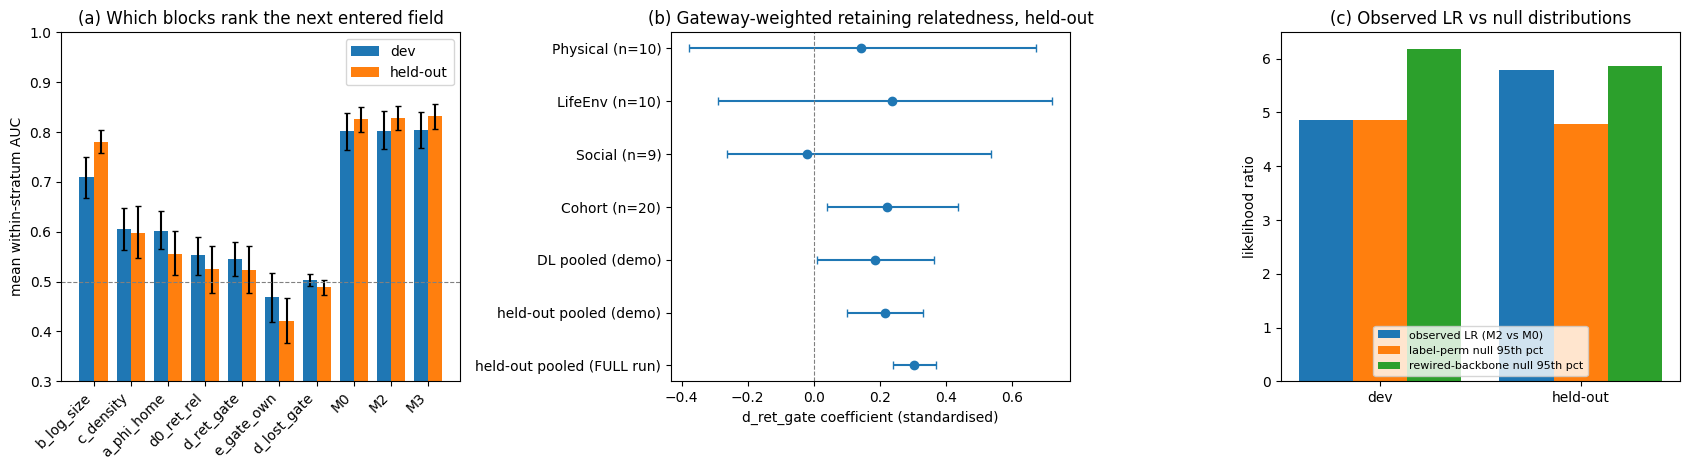

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (a) within-stratum AUC of each single regressor and each model block (dev vs held-out, demo)
keys = ["b_log_size", "c_density", "a_phi_home", "d0_ret_rel", "d_ret_gate", "e_gate_own", "d_lost_gate", "M0", "M2", "M3"]
x = np.arange(len(keys)); w = 0.38
for i, (lab, r) in enumerate((("dev", hd), ("held-out", hh))):
    m = [r["auc_within_stratum"][k]["mean"] for k in keys]
    lo_ = [m[j] - r["auc_within_stratum"][k]["ci"][0] for j, k in enumerate(keys)]
    hi_ = [r["auc_within_stratum"][k]["ci"][1] - m[j] for j, k in enumerate(keys)]
    axes[0].bar(x + (i - 0.5) * w, m, w, yerr=[lo_, hi_], capsize=2, label=lab)
axes[0].axhline(0.5, color="grey", lw=0.8, ls="--")
axes[0].set_xticks(x); axes[0].set_xticklabels(keys, rotation=45, ha="right")
axes[0].set_ylim(0.3, 1.0); axes[0].set_ylabel("mean within-stratum AUC"); axes[0].set_title("(a) Which blocks rank the next entered field")
axes[0].legend()

# (b) forest plot of d_ret_gate per held-out group, plus pooled estimates
lab, est, lo_, hi_ = [], [], [], []
for g in HELD_GROUPS:
    p = heldout_result["H2_per_group"].get(g, {})
    if "d" in p:
        lab.append(f"{g} (n={p['n_concepts']})"); est.append(p["d"]); lo_.append(p["boot_ci"][0]); hi_.append(p["boot_ci"][1])
dl = heldout_result["H2_DL_pooled"]
lab.append("DL pooled (demo)"); est.append(dl["b"]); lo_.append(dl["ci"][0]); hi_.append(dl["ci"][1])
lab.append("held-out pooled (demo)"); est.append(hh["models"]["M2"]["coef"]["d_ret_gate"]); lo_.append(hh["boot_d"]["ci"][0]); hi_.append(hh["boot_d"]["ci"][1])
lab.append("held-out pooled (FULL run)"); est.append(ref["heldout_d"]); lo_.append(ref["heldout_boot_d_ci"][0]); hi_.append(ref["heldout_boot_d_ci"][1])
y = np.arange(len(lab))[::-1]
axes[1].errorbar(est, y, xerr=[np.array(est) - np.array(lo_), np.array(hi_) - np.array(est)], fmt="o", capsize=3)
axes[1].axvline(0, color="grey", lw=0.8, ls="--")
axes[1].set_yticks(y); axes[1].set_yticklabels(lab); axes[1].set_xlabel("d_ret_gate coefficient (standardised)")
axes[1].set_title("(b) Gateway-weighted retaining relatedness, held-out")

# (c) observed LR vs rewired / permutation null quantiles
names = ["dev", "held-out"]
obs = [hd["LR"]["M2_vs_M0"]["LR"], hh["LR"]["M2_vs_M0"]["LR"]]
perm95 = [hd["perm_null"]["null_q"][2], hh["perm_null"]["null_q"][2]]
rew95 = [hd["rewired_null"]["null_q95"], hh["rewired_null"]["null_q95"]]
xx = np.arange(2); w = 0.27
axes[2].bar(xx - w, obs, w, label="observed LR (M2 vs M0)")
axes[2].bar(xx, perm95, w, label="label-perm null 95th pct")
axes[2].bar(xx + w, rew95, w, label="rewired-backbone null 95th pct")
axes[2].set_xticks(xx); axes[2].set_xticklabels(names); axes[2].set_ylabel("likelihood ratio")
axes[2].set_title("(c) Observed LR vs null distributions"); axes[2].legend(fontsize=8, loc="lower center")
plt.tight_layout(); plt.show()